# compare.ipynb — 两段音频端到端对齐与推理对比
填入两段音频的路径，复用训练同配置的预处理/模型，检查能量、频谱、窗口对齐和阈值敏感性。


In [1]:
# Imports & config
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from types import SimpleNamespace
import librosa.display
import torch
from IPython.display import Audio, display

from src.config import (SR, N_MELS, N_FFT, HOP_LENGTH, MEL_CENTER, WINDOW_SECONDS, WINDOW_HOP, MEL_TARGET_FRAMES, TARGET_LABELS, LABEL_TO_ID, NUM_CLASSES, SEED)
from src.preprocess import files_to_slices_and_batch, log_mel
from src.inference import load_torch_checkpoint, run_torch_inference

sns.set_theme(style='whitegrid')
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
CHECKPOINT_PATH = Path('cache/experiments/tinyglassnet_best.pt')  # 可按需修改
THRESHOLDS = {lab: 0.5 for lab in TARGET_LABELS}


In [2]:
# 待比较的两段音频路径（自行填写）
AUDIO_A = Path('data/freesound/glass_ext_04.wav')  # TODO: 填入文件路径
AUDIO_B = Path('data/custom/audio/glass_ext_04_iphone.mp3')  # TODO: 填入文件路径
AUDIO_LIST = [AUDIO_A, AUDIO_B]
assert all(p.exists() for p in AUDIO_LIST), '请先填入存在的音频路径'


In [3]:
# 统一预处理：resample->mono->切窗->mel->pad/crop（与训练一致），并额外加入 AUDIO_B 的 +10dB 版本
def prep_audio(paths):
    recs, slices, batch_np = files_to_slices_and_batch(
        paths, target_sr=SR, mono=True,
        window_seconds=float(WINDOW_SECONDS), hop_seconds=float(WINDOW_HOP),
        target_frames=MEL_TARGET_FRAMES,
        n_fft=N_FFT, hop_length=HOP_LENGTH, n_mels=N_MELS, center=MEL_CENTER,
        max_files=None, max_slices_per_file=None, seed=SEED,
        normalize=True,          # 开启
        norm_mode="rms",         # 或 "absmax"
        # norm_target_rms=0.1,     # RMS 目标
        # norm_gain_db=10.0,       # 可选额外抬升
    )
    rows = []
    for s in slices:
        rows.append({
            'file': s.path.name, 'path': s.path, 'start_sec': s.start_sec,
            'duration_sec': s.duration_sec,
            'absmax': float(np.max(np.abs(s.wave))) if len(s.wave)>0 else 0.0,
            'rms': float(np.sqrt(np.mean(s.wave**2))) if len(s.wave)>0 else 0.0,
            'frames': s.mel.shape[-1],
        })
    df = pd.DataFrame(rows)
    return recs, slices, batch_np, df

recs, slices, batch_np, meta_df = prep_audio(AUDIO_LIST)


In [4]:
# 为 AUDIO_B 生成 +10dB 版 和 平移版（独立加入）
GAIN_DB = 1.0
SHIFT_RATIO = 0.19  # 例如 0.1 表示把前 10% 循环移到末尾

gain_slices, gain_rows = [], []
shift_slices, shift_rows = [], []

for s in slices:
    is_b = (s.path == AUDIO_B)
    y_base = s.wave
    # 10dB 版本（仅 AUDIO_B）
    if is_b:
        y_gain = y_base
        if np.max(np.abs(y_gain)) > 0:
            y_gain = y_gain / np.max(np.abs(y_gain))
        y_gain = y_gain * (10 ** (GAIN_DB / 20))
        mel_gain = log_mel(y_gain, sr=SR, n_mels=N_MELS, n_fft=N_FFT, hop_length=HOP_LENGTH, center=MEL_CENTER)
        tgt = MEL_TARGET_FRAMES if MEL_TARGET_FRAMES is not None else mel_gain.shape[1]
        if mel_gain.shape[1] > tgt:
            mel_gain = mel_gain[:, :tgt]
        elif mel_gain.shape[1] < tgt:
            mel_gain = np.pad(mel_gain, ((0, 0), (0, tgt - mel_gain.shape[1])))
        gain_slices.append(SimpleNamespace(path=Path(str(s.path) + "_gain"),
                                           start_sec=s.start_sec, duration_sec=s.duration_sec,
                                           wave=y_gain, mel=mel_gain))
        gain_rows.append({
            "file": s.path.name + "+10dB", "path": Path(str(s.path) + "_gain"),
            "start_sec": s.start_sec, "duration_sec": s.duration_sec,
            "absmax": float(np.max(np.abs(y_gain))) if len(y_gain) > 0 else 0.0,
            "rms": float(np.sqrt(np.mean(y_gain ** 2))) if len(y_gain) > 0 else 0.0,
            "frames": mel_gain.shape[-1],
        })

        # 平移版本（仅 AUDIO_B）
        shift_samples = int(round(len(y_base) * SHIFT_RATIO))
        if shift_samples > 0:
            y_shift = np.concatenate([y_base[shift_samples:], y_base[:shift_samples]])
        else:
            y_shift = y_base
        mel_shift = log_mel(y_shift, sr=SR, n_mels=N_MELS, n_fft=N_FFT, hop_length=HOP_LENGTH, center=MEL_CENTER)
        tgt = MEL_TARGET_FRAMES if MEL_TARGET_FRAMES is not None else mel_shift.shape[1]
        if mel_shift.shape[1] > tgt:
            mel_shift = mel_shift[:, :tgt]
        elif mel_shift.shape[1] < tgt:
            mel_shift = np.pad(mel_shift, ((0, 0), (0, tgt - mel_shift.shape[1])))
        shift_slices.append(SimpleNamespace(path=Path(str(s.path) + "_shift"),
                                            start_sec=s.start_sec, duration_sec=s.duration_sec,
                                            wave=y_shift, mel=mel_shift))
        shift_rows.append({
            "file": s.path.name + f"+shift{SHIFT_RATIO:.2f}", "path": Path(str(s.path) + "_shift"),
            "start_sec": s.start_sec, "duration_sec": s.duration_sec,
            "absmax": float(np.max(np.abs(y_shift))) if len(y_shift) > 0 else 0.0,
            "rms": float(np.sqrt(np.mean(y_shift ** 2))) if len(y_shift) > 0 else 0.0,
            "frames": mel_shift.shape[-1],
        })

# 合并
slices = list(slices) + gain_slices + shift_slices
extra_rows = []
if gain_rows:
    extra_rows.extend(gain_rows)
if shift_rows:
    extra_rows.extend(shift_rows)
meta_df = pd.concat([meta_df, pd.DataFrame(extra_rows)], ignore_index=True) if extra_rows else meta_df


In [5]:
# 生成 gain + shift 版本（平移后再增益）
SHIFT_RATIO = 0.19  # 10% 循环移位
GAIN_DB = 1.0

gain_shift_slices = []
gain_shift_rows = []

for s in slices:  # slices 此时包含原/iphone窗口
    if s.path.name.endswith(".mp3"):  # 针对 iphone 录音；如需更严格匹配可改条件
        y_base = s.wave
        shift_samples = int(round(len(y_base) * SHIFT_RATIO))
        if shift_samples > 0:
            y_shift = np.concatenate([y_base[shift_samples:], y_base[:shift_samples]])
        else:
            y_shift = y_base
        # 归一化后再加增益
        if np.max(np.abs(y_shift)) > 0:
            y_shift = y_shift / np.max(np.abs(y_shift))
        y_shift = y_shift * (10 ** (GAIN_DB / 20))

        mel = log_mel(y_shift, sr=SR, n_mels=N_MELS, n_fft=N_FFT, hop_length=HOP_LENGTH, center=MEL_CENTER)
        tgt = MEL_TARGET_FRAMES if MEL_TARGET_FRAMES is not None else mel.shape[1]
        if mel.shape[1] > tgt:
            mel = mel[:, :tgt]
        elif mel.shape[1] < tgt:
            mel = np.pad(mel, ((0, 0), (0, tgt - mel.shape[1])))

        p_out = Path(str(s.path) + f"_shift{SHIFT_RATIO}_gain{GAIN_DB}")
        gain_shift_slices.append(SimpleNamespace(path=p_out, start_sec=s.start_sec,
                                                 duration_sec=s.duration_sec, wave=y_shift, mel=mel))
        gain_shift_rows.append({
            "file": p_out.name,
            "path": p_out,
            "start_sec": s.start_sec,
            "duration_sec": s.duration_sec,
            "absmax": float(np.max(np.abs(y_shift))) if len(y_shift) > 0 else 0.0,
            "rms": float(np.sqrt(np.mean(y_shift ** 2))) if len(y_shift) > 0 else 0.0,
            "frames": mel.shape[-1],
        })


In [14]:
# 合并并去重：原始 slices + gain_slices + shift_slices
all_tmp = []
all_tmp.extend(list(slices))        # 前面已经生成的原/iphone窗口
all_tmp.extend(gain_slices)         # mp3_gain
all_tmp.extend(shift_slices)        # mp3_shift
all_tmp.extend(gain_shift_slices)   # mp3_shift+gain

uniq = {}
for s in all_tmp:
    uniq[s.path.name] = s  # 同名只保留最后一个
slices = list(uniq.values())        # 最终唯一列表

print("Final slices:", [s.path.name for s in slices])

# 重建 meta_df
meta_rows = []
for s in slices:
    meta_rows.append({
        "file": s.path.name,
        "path": s.path,
        "start_sec": s.start_sec,
        "duration_sec": s.duration_sec,
        "absmax": float(np.max(np.abs(s.wave))) if len(s.wave) > 0 else 0.0,
        "rms": float(np.sqrt(np.mean(s.wave ** 2))) if len(s.wave) > 0 else 0.0,
        "frames": s.mel.shape[-1],
    })
meta_df = pd.DataFrame(meta_rows)

# 推理
batch_np = np.stack([s.mel for s in slices])[:, None, :, :]
batch = torch.from_numpy(batch_np).float().to(DEVICE)

model, payload = load_torch_checkpoint(CHECKPOINT_PATH, device=DEVICE, num_classes=NUM_CLASSES)
logits = model(batch)
probs = torch.sigmoid(logits).detach().cpu().numpy()  # 先 detach 再 numpy

# 后续 rows 构建保持不变
rows = []
n_rows, n_cols = probs.shape
for i, s in enumerate(slices):
    if i >= n_rows:
        break
    row = {"file": s.path.name, "start_sec": s.start_sec, "duration_sec": s.duration_sec}
    for lab, idx in LABEL_TO_ID.items():
        if idx < n_cols:
            row[f"prob_{lab}"] = float(probs[i, idx])
    rows.append(row)

pred_df = pd.DataFrame(rows)
print("unique files:", pred_df["file"].unique())

meta_df = pd.DataFrame(meta_rows)
print(meta_df.groupby("file").agg({"start_sec":"count","absmax":["median","min"],"rms":["median","min"],"frames":"unique"}))

print("batch stats:", batch.shape, batch.min().item(), batch.max().item(), batch.mean().item())
print("logits min/max:", torch_res.logits.min().item(), torch_res.logits.max().item())
print("probs min/max:", torch_res.probs.min().item(), torch_res.probs.max().item())
print("per-file probs:", pred_df[['file'] + [c for c in pred_df.columns if c.startswith('prob_')]].head(10))

Final slices: ['glass_ext_04.wav', 'glass_ext_04_iphone.mp3', 'glass_ext_04_iphone.mp3_gain', 'glass_ext_04_iphone.mp3_shift', 'glass_ext_04_iphone.mp3_shift0.19_gain1.0']
unique files: ['glass_ext_04.wav' 'glass_ext_04_iphone.mp3' 'glass_ext_04_iphone.mp3_gain' 'glass_ext_04_iphone.mp3_shift' 'glass_ext_04_iphone.mp3_shift0.19_gain1.0']
                                          start_sec    absmax            \
                                              count    median       min   
file                                                                      
glass_ext_04.wav                                  1  1.308608  1.308608   
glass_ext_04_iphone.mp3                           1  0.567963  0.567963   
glass_ext_04_iphone.mp3_gain                      1  1.122018  1.122018   
glass_ext_04_iphone.mp3_shift                     1  0.567963  0.567963   
glass_ext_04_iphone.mp3_shift0.19_gain1.0         1  1.122018  1.122018   

                                                rms        

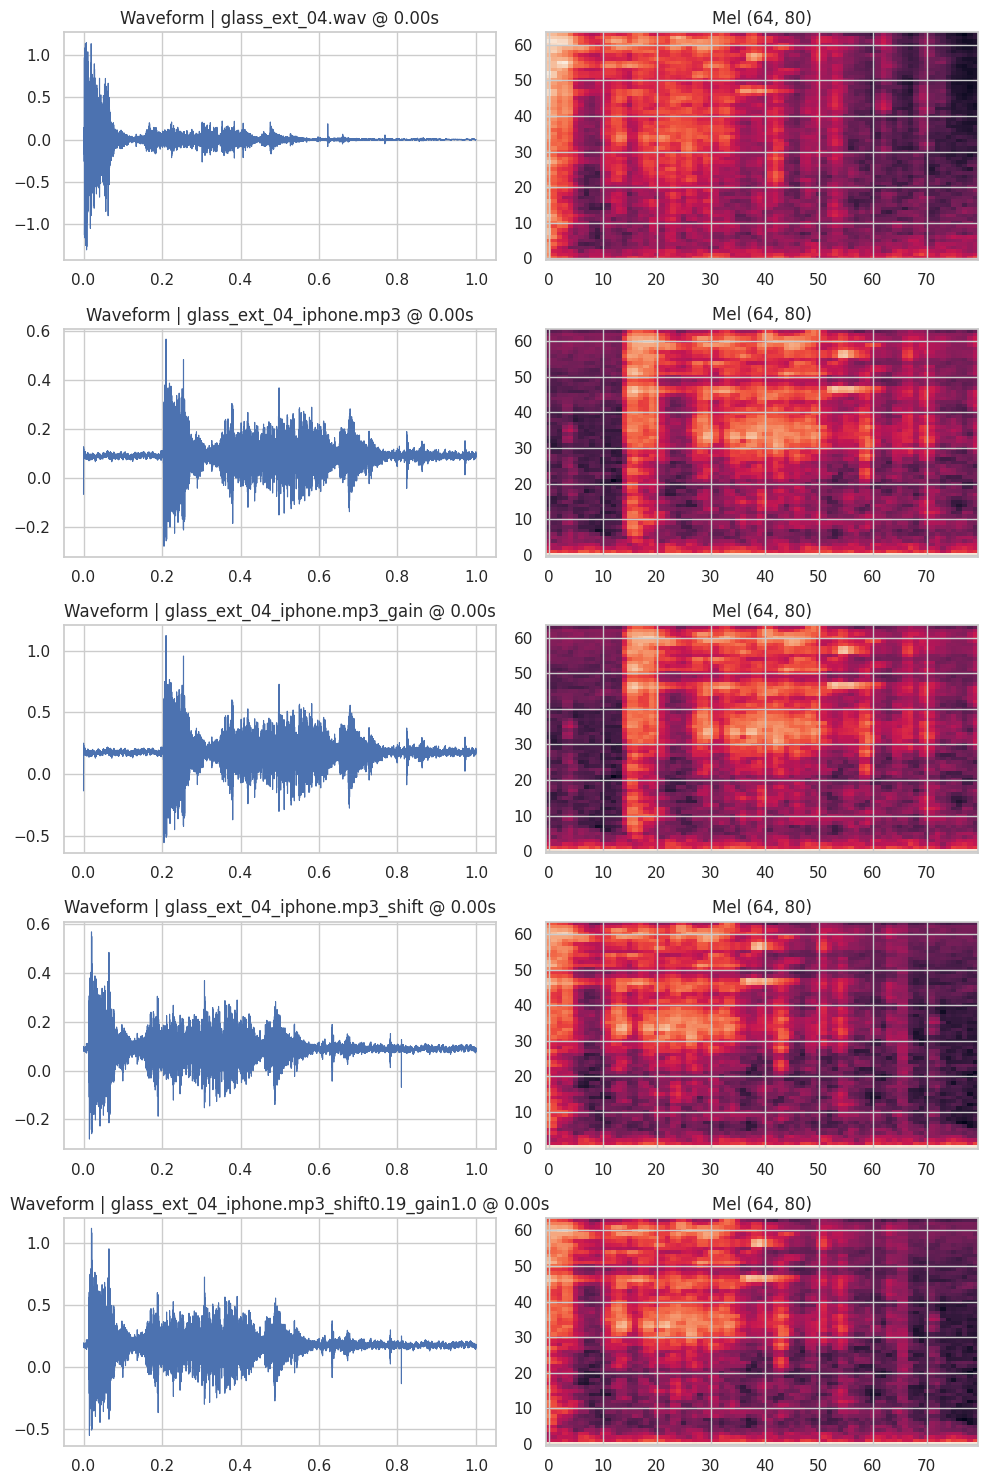

In [7]:
# 可视化：每个音频抽几窗波形+mel
def viz_samples(slices, max_per_file=2):
    picked = []
    by_file = {}
    for s in slices:
        by_file.setdefault(s.path.name, []).append(s)
    for fname, lst in by_file.items():
        for s in lst[:max_per_file]:
            picked.append((fname, s))
    rows = len(picked)
    fig, axes = plt.subplots(rows, 2, figsize=(10, 3*rows))
    axes = np.atleast_2d(axes)
    for i, (fname, s) in enumerate(picked):
        t = np.arange(len(s.wave))/SR
        axes[i,0].plot(t, s.wave, lw=0.8)
        axes[i,0].set_title('Waveform | {} @ {:.2f}s'.format(fname, s.start_sec))
        axes[i,1].imshow(s.mel, origin='lower', aspect='auto')
        axes[i,1].set_title('Mel {}'.format(s.mel.shape))
    plt.tight_layout(); plt.show()

viz_samples(slices, max_per_file=2)


In [8]:
# Mel array 全量打印：遍历 slices 中的每个窗口
import numpy as np
# np.set_printoptions(precision=3, suppress=True, linewidth=240)
np.set_printoptions(precision=3, suppress=True, linewidth=240)

if not slices:
    print("No mel collected.")
else:
    base = slices[0]
    base_name = base.path.name if hasattr(base, "path") else "base"
    base_mel = base.mel
    print(f"[base] {base_name} | start={getattr(base, 'start_sec', 0):.2f}s | mel shape={base_mel.shape}")
    print(base_mel)

    for s in slices[1:]:
        name = s.path.name if hasattr(s, "path") else "unknown"
        mel = s.mel
        print(f"\n{name} | start={getattr(s, 'start_sec', 0):.2f}s | mel shape={mel.shape}")
        print(mel)
        if mel.shape == base_mel.shape:
            diff = mel - base_mel
            print(f"abs diff vs {base_name}: max={np.abs(diff).max():.4f}, mean={np.abs(diff).mean():.4f}")
        else:
            print(f"shape mismatch vs base ({base_mel.shape}), skip diff.")

    print(f"\nTotal slices printed: {len(slices)}")


[base] glass_ext_04.wav | start=0.00s | mel shape=(64, 80)
[[-13.613 -23.1   -27.208 ... -35.467 -30.956 -27.092]
 [-16.011 -29.334 -32.993 ... -36.644 -37.051 -34.318]
 [-14.089 -32.776 -33.821 ... -40.4   -42.316 -40.608]
 ...
 [ -0.733  -1.468  -3.353 ... -63.869 -63.719 -62.262]
 [ -3.972  -5.516  -6.191 ... -62.762 -60.735 -58.586]
 [ -6.98   -8.769 -11.986 ... -67.163 -62.761 -59.07 ]]

glass_ext_04_iphone.mp3 | start=0.00s | mel shape=(64, 80)
[[ -0.993  -0.769  -0.562 ...  -0.571  -0.868  -0.78 ]
 [-24.14  -22.766 -24.798 ... -23.629 -26.159 -24.921]
 [-29.452 -34.107 -33.701 ... -26.181 -28.206 -29.915]
 ...
 [-37.767 -38.304 -39.813 ... -38.714 -33.207 -29.355]
 [-40.075 -39.325 -38.905 ... -38.471 -36.816 -32.942]
 [-45.043 -43.66  -42.978 ... -41.436 -44.749 -41.763]]
abs diff vs glass_ext_04.wav: max=44.0831, mean=12.4595

glass_ext_04_iphone.mp3_gain | start=0.00s | mel shape=(64, 80)
[[ -0.993  -0.769  -0.562 ...  -0.571  -0.868  -0.78 ]
 [-24.14  -22.766 -24.798 ... -23

In [9]:
np.set_printoptions(precision=3, suppress=True, linewidth=200)

def print_full_mel(name, mel):
    print(f"\n[{name}] shape={mel.shape}")
    print(mel)

# 假设你有一个字典或列表存好这些 mel
mels = {
    "old_filter_gun3.wav": base_mel,           # 替换为实际变量
    "old_filter_gun3.wav_gain": mel_gain,
    "old_filter_gun3.wav_shift": mel_shift,
}

for k, v in mels.items():
    print_full_mel(k, v)


[old_filter_gun3.wav] shape=(64, 80)
[[-13.613 -23.1   -27.208 ... -35.467 -30.956 -27.092]
 [-16.011 -29.334 -32.993 ... -36.644 -37.051 -34.318]
 [-14.089 -32.776 -33.821 ... -40.4   -42.316 -40.608]
 ...
 [ -0.733  -1.468  -3.353 ... -63.869 -63.719 -62.262]
 [ -3.972  -5.516  -6.191 ... -62.762 -60.735 -58.586]
 [ -6.98   -8.769 -11.986 ... -67.163 -62.761 -59.07 ]]

[old_filter_gun3.wav_gain] shape=(64, 80)
[[ -0.993  -0.769  -0.562 ...  -0.571  -0.868  -0.78 ]
 [-24.14  -22.766 -24.798 ... -23.629 -26.159 -24.921]
 [-29.452 -34.107 -33.701 ... -26.181 -28.206 -29.915]
 ...
 [-37.767 -38.304 -39.813 ... -38.714 -33.207 -29.355]
 [-40.075 -39.325 -38.905 ... -38.471 -36.816 -32.942]
 [-45.043 -43.66  -42.978 ... -41.436 -44.749 -41.763]]

[old_filter_gun3.wav_shift] shape=(64, 80)
[[ -1.008  -0.763  -0.96  ...  -0.749  -0.287  -0.428]
 [-29.023 -27.87  -27.786 ... -21.823 -26.281 -21.38 ]
 [-31.898 -32.102 -28.811 ... -28.568 -30.533 -31.675]
 ...
 [-10.351  -9.735 -10.825 ... -38

In [10]:
# 模型推理
model, payload = load_torch_checkpoint(CHECKPOINT_PATH, device=DEVICE, num_classes=NUM_CLASSES)
torch_res = run_torch_inference(model, batch, device=DEVICE, threshold=None)
probs = torch_res.probs
# rows = []
# for i, s in enumerate(slices):
#     row = {'file': s.path.name, 'start_sec': s.start_sec, 'duration_sec': s.duration_sec}
#     for lab, idx in LABEL_TO_ID.items():
#         row['prob_{}'.format(lab)] = probs[i, idx].item()
#     rows.append(row)
# pred_df = pd.DataFrame(rows)
# display(pred_df.head())
# print('阈值=0.5 时命中数:')
# for lab in TARGET_LABELS:
#     col = 'prob_{}'.format(lab)
#     hit = pred_df[pred_df[col] >= THRESHOLDS.get(lab,0.5)]
#     print(lab, hit.groupby('file').size().to_dict())


rows = []
n_rows = probs.shape[0]
for i in range(n_rows):
    s = slices[i]
    row = {"file": s.path.name, "start_sec": s.start_sec, "duration_sec": s.duration_sec}
    for lab, idx in LABEL_TO_ID.items():
        if idx < probs.shape[1]:
            row[f"prob_{lab}"] = float(probs[i, idx])
    rows.append(row)
pred_df = pd.DataFrame(rows)
print("unique files:", pred_df['file'].unique())




unique files: ['glass_ext_04.wav' 'glass_ext_04_iphone.mp3' 'glass_ext_04_iphone.mp3_gain' 'glass_ext_04_iphone.mp3_shift' 'glass_ext_04_iphone.mp3_shift0.19_gain1.0']


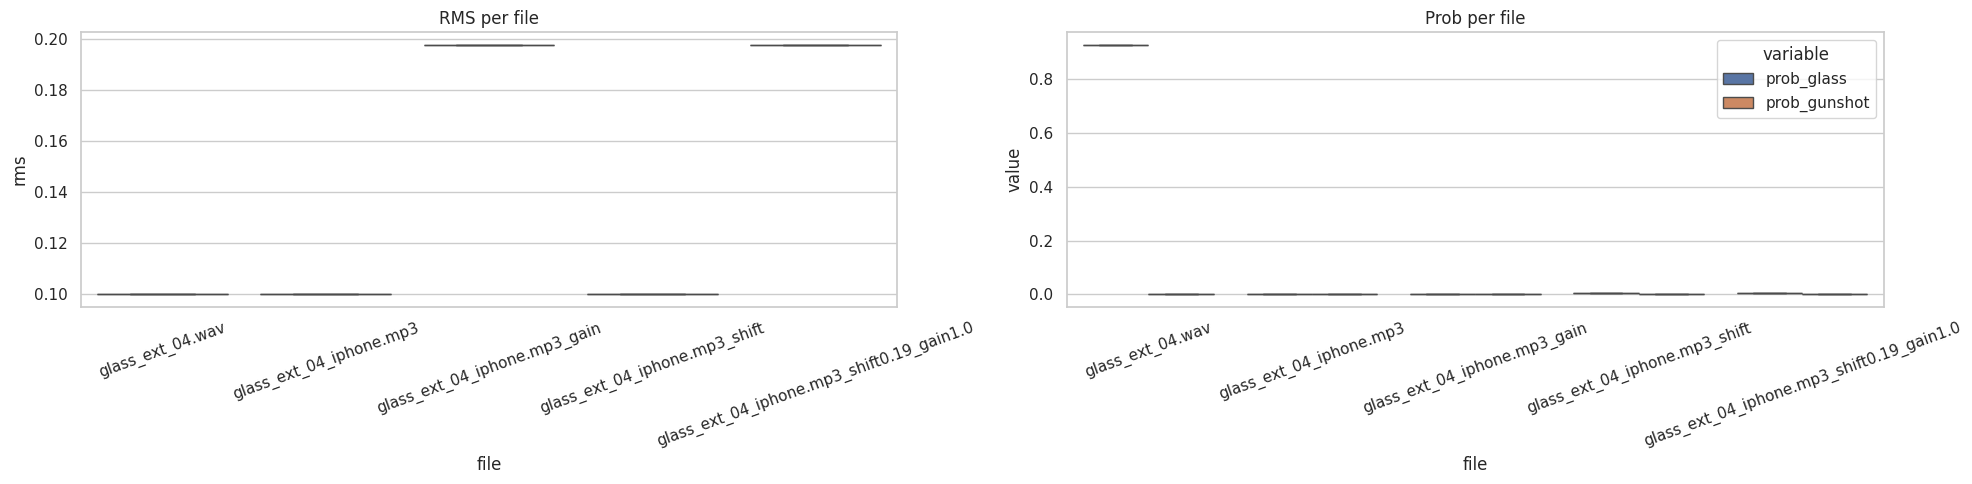

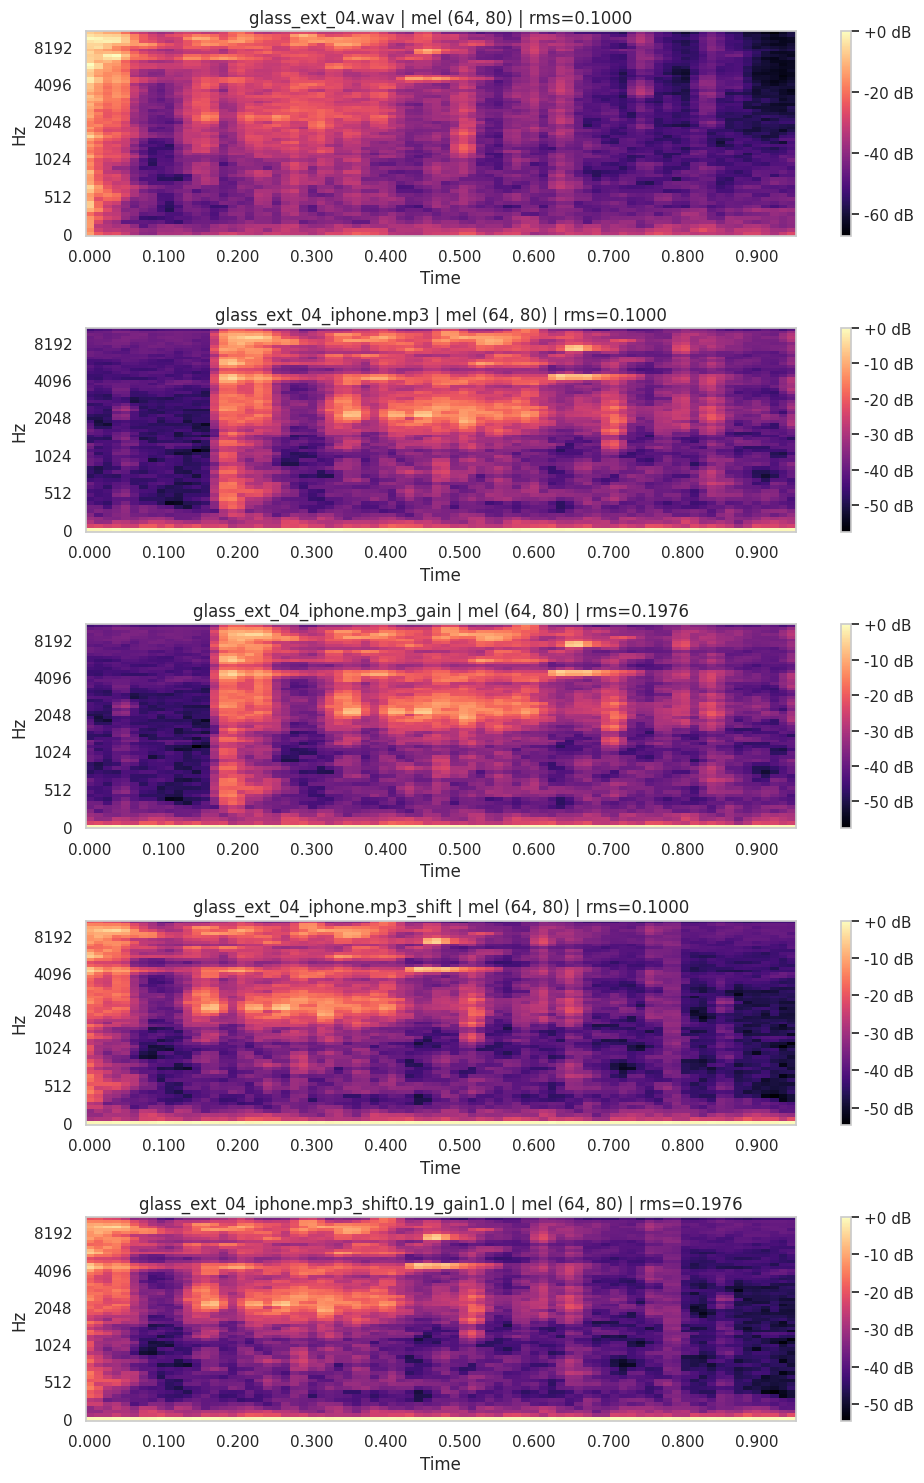

In [11]:
# 能量/分数分布对比 + mel 可视化（抽样）
fig, axes = plt.subplots(1, 2, figsize=(20, 5))
sns.boxplot(data=meta_df, x='file', y='rms', ax=axes[0])
axes[0].set_title('RMS per file')
axes[0].tick_params(axis='x', rotation=20)

long_prob = pred_df.melt(id_vars=['file'], value_vars=['prob_'+l for l in TARGET_LABELS])
sns.boxplot(data=long_prob, x='file', y='value', hue='variable', ax=axes[1])
axes[1].set_title('Prob per file')
axes[1].tick_params(axis='x', rotation=20)
plt.tight_layout()
plt.show()

# 额外：抽样几条 mel 展示（原始 vs +10dB）
def show_mels(slices, max_per_file=1):
    picked = []
    by_file = {}
    for s in slices:
        by_file.setdefault(s.path.name, []).append(s)
    for fname, lst in by_file.items():
        for s in lst[:max_per_file]:
            picked.append((fname, s))
    rows = len(picked)
    fig, axes = plt.subplots(rows, 1, figsize=(10, 3*rows))
    axes = np.atleast_1d(axes)
    for ax, (fname, s) in zip(axes, picked):
        img = librosa.display.specshow(
            s.mel, sr=SR, hop_length=HOP_LENGTH, x_axis="time", y_axis="mel", ax=ax
        )
        ax.set_title(f"{fname} | mel {s.mel.shape} | rms={np.sqrt(np.mean(s.wave**2)):.4f}")
        fig.colorbar(img, ax=ax, format="%+0.0f dB")
    plt.tight_layout()
    plt.show()

show_mels(slices, max_per_file=1)


glass_ext_04.wav@0.00s | mel_max mean=-39.05 min=-67.16 max=0.00
mel_ref1 mean=-29.16 min=-57.28 max=9.89 | abs diff max=9.89, mean=9.89


/tmp/ipykernel_9235/3827621327.py:27: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.colorbar(img, ax=axes, format="%+0.0f dB"); plt.tight_layout(); plt.show()


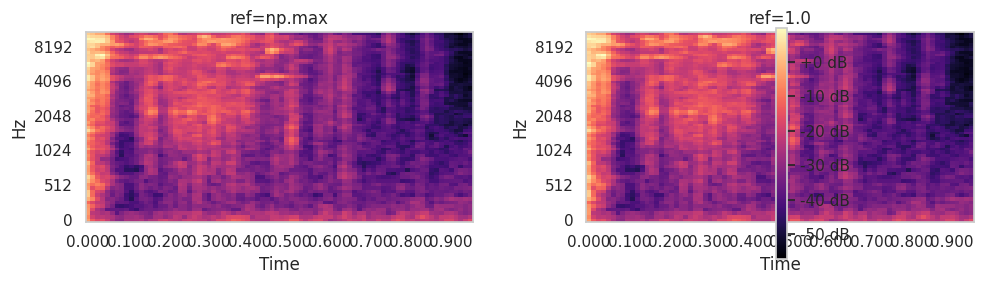

glass_ext_04_iphone.mp3@0.00s | mel_max mean=-32.37 min=-57.60 max=0.00
mel_ref1 mean=-25.45 min=-50.68 max=6.92 | abs diff max=6.92, mean=6.92


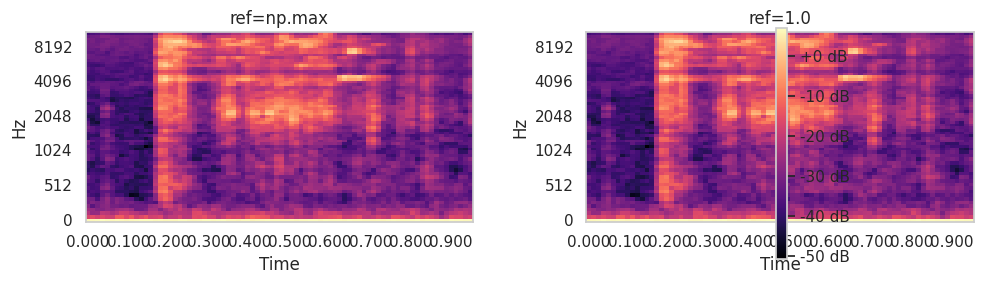

glass_ext_04_iphone.mp3_gain@0.00s | mel_max mean=-32.37 min=-57.60 max=0.00
mel_ref1 mean=-19.54 min=-44.77 max=12.83 | abs diff max=12.83, mean=12.83


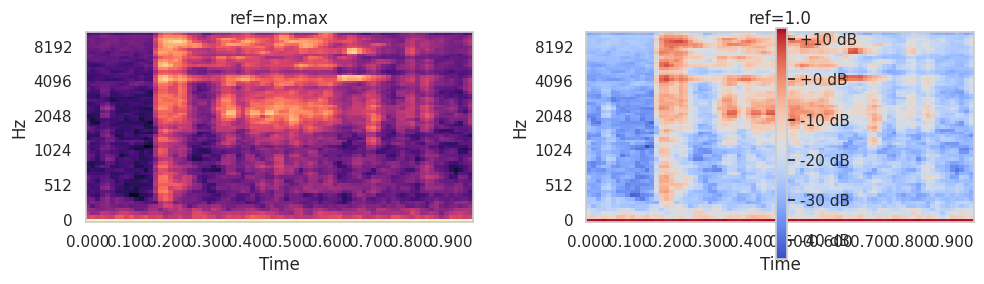

glass_ext_04_iphone.mp3_shift@0.00s | mel_max mean=-32.49 min=-54.53 max=0.00
mel_ref1 mean=-25.54 min=-47.58 max=6.95 | abs diff max=6.95, mean=6.95


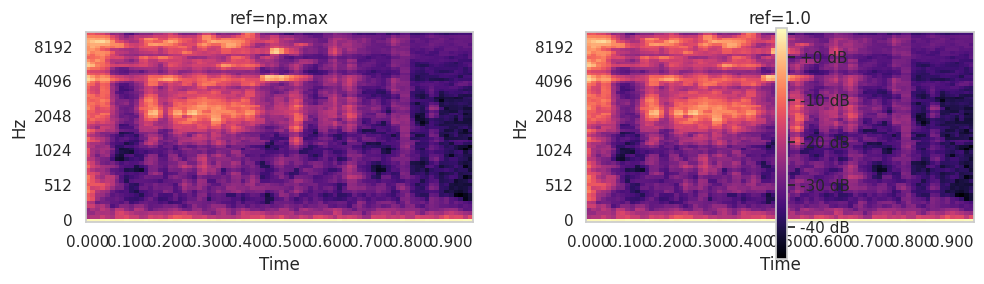

glass_ext_04_iphone.mp3_shift0.19_gain1.0@0.00s | mel_max mean=-32.49 min=-54.53 max=0.00
mel_ref1 mean=-19.63 min=-41.67 max=12.86 | abs diff max=12.86, mean=12.86


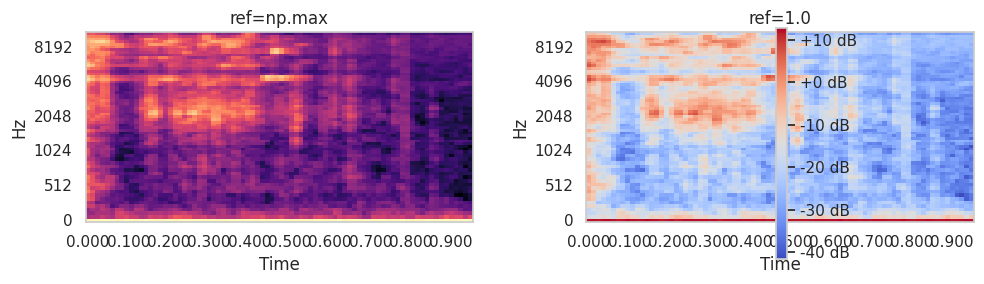

In [12]:
# 诊断：固定 dB 参考，直接看绝对能量/频响差异
import librosa, numpy as np, matplotlib.pyplot as plt, librosa.display

DB_REF_MAX = True      # 正常保持 True，与训练一致
DB_REF_TEST = False    # 设为 True 时，用 ref=1.0 仅做对比，不用来推理

def mel_with_ref(y, sr, ref_max=True):
    mel_power = librosa.feature.melspectrogram(
        y=y, sr=sr, n_fft=N_FFT, hop_length=HOP_LENGTH, n_mels=N_MELS, center=MEL_CENTER
    )
    if ref_max:
        return librosa.power_to_db(mel_power, ref=np.max)
    else:
        return librosa.power_to_db(mel_power, ref=1.0)

# 对当前 slices 的前几窗做双版本 mel 并打印/对比
for s in slices:
    mel_max = mel_with_ref(s.wave, SR, ref_max=True)
    mel_ref1 = mel_with_ref(s.wave, SR, ref_max=False)
    diff = np.abs(mel_ref1 - mel_max)
    print(f"{s.path.name}@{s.start_sec:.2f}s | mel_max mean={mel_max.mean():.2f} min={mel_max.min():.2f} max={mel_max.max():.2f}")
    print(f"mel_ref1 mean={mel_ref1.mean():.2f} min={mel_ref1.min():.2f} max={mel_ref1.max():.2f} | abs diff max={diff.max():.2f}, mean={diff.mean():.2f}")

    fig, axes = plt.subplots(1,2, figsize=(10,3))
    librosa.display.specshow(mel_max, sr=SR, hop_length=HOP_LENGTH, x_axis="time", y_axis="mel", ax=axes[0]); axes[0].set_title("ref=np.max")
    img = librosa.display.specshow(mel_ref1, sr=SR, hop_length=HOP_LENGTH, x_axis="time", y_axis="mel", ax=axes[1]); axes[1].set_title("ref=1.0")
    fig.colorbar(img, ax=axes, format="%+0.0f dB"); plt.tight_layout(); plt.show()
    # if DB_REF_MAX: break  # 只看一条
